# KSSL

> Various Transforms to be piped to create a DataLoader

In [ ]:
#| default_exp data.transforms.kssl

In [ ]:
#| export
from __future__ import annotations
from fastai.vision.all import *
from fastai.data.all import *
from fastcore.basics import patch
from pathlib import Path
import pandas as pd

In [ ]:
#| hide
from nbdev.showdoc import *
from nbdev.cli import *

## Input (spectra)

In [ ]:
#|eval: false
path = Path('../_data/kssl-mirs')

In [ ]:
#| export
@Transform
def get_spectra_files(path:Path, # Directory that contains spectra replicates and wet chemistry
                     ) -> L: # List of spectra replicates (if any) file paths in the directory
    "Return list of paths to spectra `.csv` files"
    return L(fname for fname in path.ls() if re.match('\d', fname.name))

In [ ]:
#|eval: false
get_spectra_files(path.ls()[0])

(#4) [Path('../_data/kssl-mirs/180338/260043XS04.csv'),Path('../_data/kssl-mirs/180338/260043XS01.csv'),Path('../_data/kssl-mirs/180338/260043XS02.csv'),Path('../_data/kssl-mirs/180338/260043XS03.csv')]

In [ ]:
wn = np.arange(4000, 600, -2); wn

array([4000, 3998, 3996, ...,  606,  604,  602])

In [ ]:
#| export
class Spectra(Tensor): 
    def show(self, ctx=None, figsize=(12,4), **kwargs):
        spectra = self
        if ctx is None: _,ctx = plt.subplots(figsize=figsize)
        wn = np.arange(4000, 600, -2)
        #ctx.imshow(im, **{**self._show_args, **kwargs})
        ctx.set_xlim(np.max(wn), np.min(wn))
        ctx.set(xlabel='Wavenumber', ylabel='Absorbance')
        ctx.set_axisbelow(True)
        for spectrum in spectra:
            _ = ctx.plot(wn, spectrum, c='steelblue', lw=0.5)
        ctx.grid(True, which='both')
        return ctx

In [ ]:
#| export
@Transform
def to_spectra(paths:L, # List of spectra file paths
              ) -> Spectra: # Spectra
    "Transform list of spectra file paths to a torch array of dimension: (n_replicates, n_wavenumbers)"
    n = pd.read_csv(paths[0]).shape[0]
    m = len(paths)
    x = np.empty((m,n))
    for i, fname in enumerate(paths):
        x[i,:] = pd.read_csv(fname)['absorbance'].values
    return Spectra(x)

In [ ]:
#|eval: false
paths = L(Path('../_data/kssl-mirs/180338/260043XS04.csv'),
          Path('../_data/kssl-mirs/180338/260043XS01.csv'),
          Path('../_data/kssl-mirs/180338/260043XS02.csv'),
          Path('../_data/kssl-mirs/180338/260043XS03.csv'))

to_spectra(paths)

Spectra([[0.1680, 0.1682, 0.1684,  ..., 1.4982, 1.4934, 1.4900],
         [0.1742, 0.1743, 0.1745,  ..., 1.5318, 1.5263, 1.5215],
         [0.1706, 0.1708, 0.1710,  ..., 1.5089, 1.5031, 1.4992],
         [0.2243, 0.2245, 0.2248,  ..., 1.5664, 1.5592, 1.5532]])

<AxesSubplot: xlabel='Wavenumber', ylabel='Absorbance'>

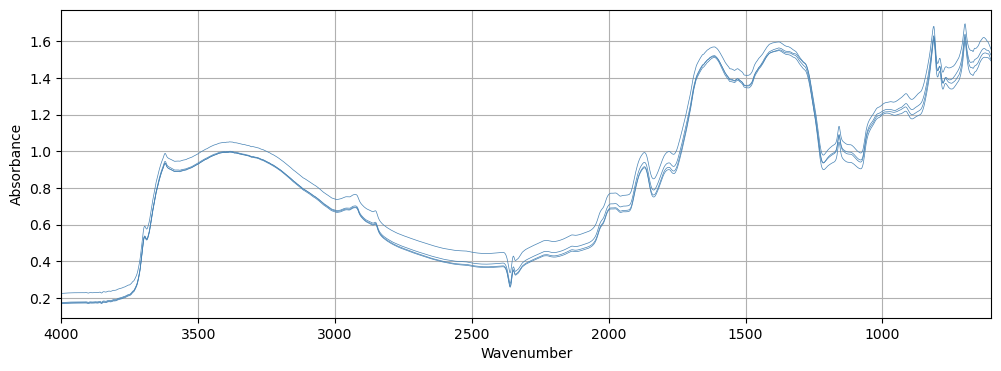

In [ ]:
to_spectra(paths).show()

In [ ]:
#| export
@Transform
def rand_w_avg(x: Spectra, # Spectra replicates (n_replicates, n_wavenumbers)
              ) -> Spectra: # Random weighted averaged spectrum
    "Transform spectra replicates taking their random weighted averages for data augmentation"
    n = len(x)
    def weights(n):
        weights = torch.rand(n)
        return (weights/weights.sum()).unsqueeze(dim=0)
    return torch.matmul(weights(n), x)

In [ ]:
#|eval: false
tls = TfmdLists(path.ls(), [get_spectra_files, to_spectra, rand_w_avg])
tls[0]

Spectra([[0.1915, 0.1918, 0.1920,  ..., 1.5329, 1.5270, 1.5222]])

## Target (Soil properties)

In [ ]:
#| export
class Analyte(Tensor): 
    def show(self, ctx=None, **kwargs):
        analytes = self
        print(analytes)

In [ ]:
#| export
class AnalytesTfm(Transform):
    def __init__(self, 
                 analytes:list|None=None): 
        self.analytes = analytes

In [ ]:
#| export
@AnalytesTfm
def encodes(self, 
            path: Path, # Path to directory containing both spectra and analyte(s) measurement
           ):
    "Transform a path to a directory into a tensor of soil analyte(s) measurement"
    path_target = [f for f in path.ls() if re.match('target', f.name)][0]
    df = pd.read_csv(path_target)
    if self.analytes:
        df = df[df.analyte.isin(self.analytes)]
    return Analyte(df['value'].values)

In [ ]:
#|eval: false
AnalytesTfm(analytes=[725])(path.ls()[0])

Analyte([2.8077])

In [ ]:
AnalytesTfm(analytes=[725])(path.ls()[0]).show()

Analyte([2.8077])


In [ ]:
#|eval: false
# Or as a TfmdLists pipeline
tls = TfmdLists(path.ls(), [AnalytesTfm(analytes=[725]), torch.log10])
tls[0]

tensor([0.4484])

In [ ]:
t = np.array([AnalytesTfm(analytes=[725])(fname).item() for fname in path.ls()])
np.log10(t.min()), np.log10(t.max())

/var/folders/9w/q9wj71814bd5m3n9gpmxn1rm0000gn/T/ipykernel_66017/2631844479.py:2: RuntimeWarning: divide by zero encountered in log10
  np.log10(t.min()), np.log10(t.max())


(-inf, 1.509618744858649)

## How to use these transforms?

1. First create two // pipes (one for the features and one for the targets):

In [ ]:
#|eval: false
x_tfms = [get_spectra_files, to_spectra, rand_w_avg]
y_tfms = [AnalytesTfm(analytes=[725]), torch.log10]

2. Create your splits and create a Fastai `Datasets`:

In [ ]:
#|eval: false
splits = RandomSplitter(seed=42)(path.ls())
dsets = Datasets(path.ls(), [x_tfms, y_tfms], splits=splits)

3. Then you get your Dataloader:

In [ ]:
#|eval: false
dls = dsets.dataloaders(bs=16)

In [ ]:
#|eval: false
dls.train.one_batch()[0].shape

torch.Size([16, 4, 1700])

In [ ]:
#|eval: false
dls.train.one_batch()[1]

Analyte([[-4.8662e-01],
         [-4.7290e-01],
         [ 4.8377e-01],
         [-9.2032e-01],
         [-6.1871e-01],
         [ 2.9790e-04],
         [-1.1769e-01],
         [-5.0147e-01],
         [-4.6117e-01],
         [-2.0003e-01],
         [       -inf],
         [-9.4657e-01],
         [-3.8762e-01],
         [-1.2586e-01],
         [-1.3596e+00],
         [-9.3043e-01]])

Analyte([-0.1432])
Analyte([0.1770])
Analyte([0.4744])
Analyte([-1.0525])


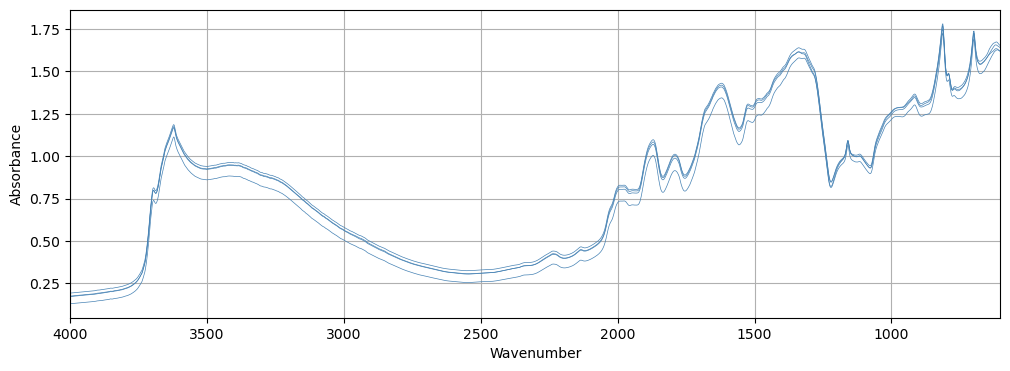

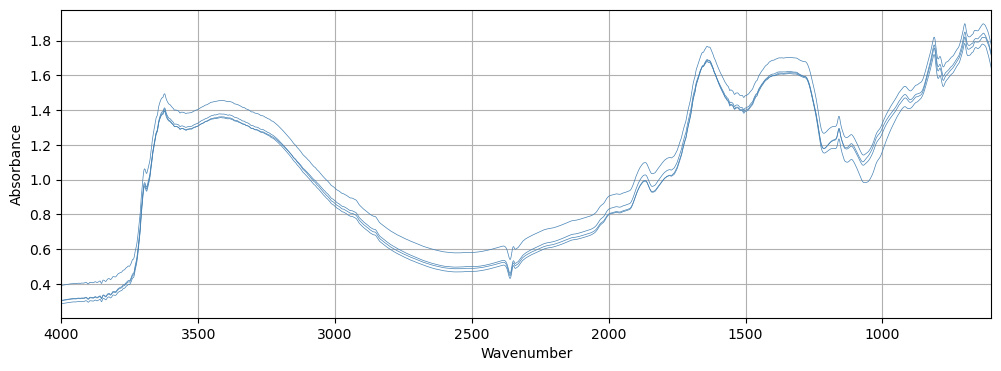

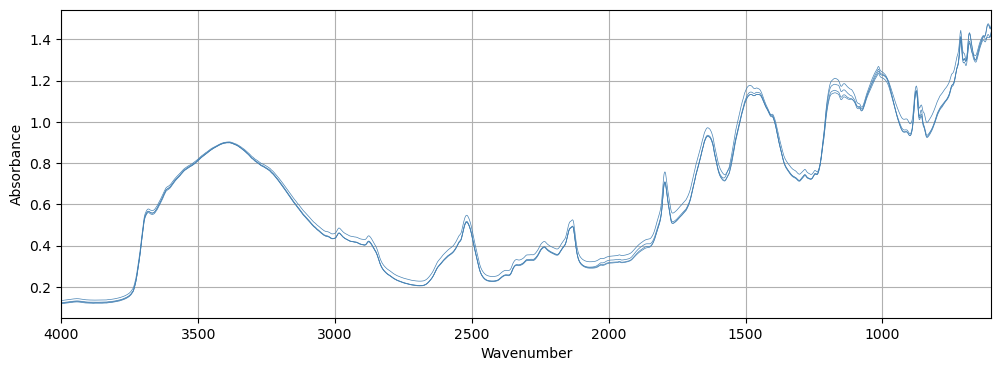

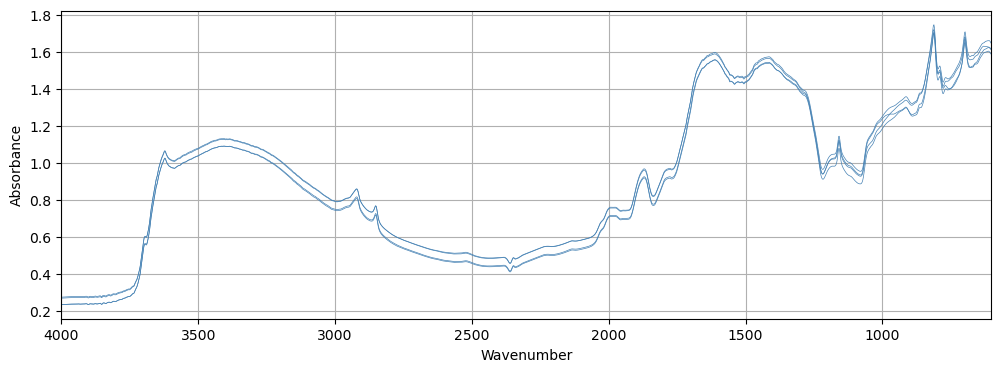

In [ ]:
dls.show_batch(max_n=4)